<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/DecisionTrees_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import google.colab
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/sales.csv')
df.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no


In [4]:
df_sales = df.copy()

In [5]:
#Encode the Nominal columns
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
#df_sales['US'] = ohe.fit_transform(df_sales[['US']]).toarray()
ohe_1_urban = ohe.fit_transform(df_sales[['Urban']])
ohe1_df = pd.DataFrame(ohe_1_urban, columns=['Urban_Cat'])
ohe_2_us = ohe.fit_transform(df_sales[['US']])
ohe_2_df = pd.DataFrame(ohe_2_us, columns=['US_Cat'])



In [6]:
df_sales_new = pd.concat([df_sales, ohe1_df,ohe_2_df],axis=1)
df_sales_new.head()

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high,Urban_Cat,US_Cat
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes,1.0,1.0
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes,1.0,1.0
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes,1.0,1.0
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no,1.0,1.0
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no,1.0,0.0


In [7]:
#Drop all text columns from df_sales_new
df_sales_new.drop(columns = ['Unnamed: 0','Urban','US'],inplace=True)


In [8]:
df_sales_new.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,high,Urban_Cat,US_Cat
0,138,73,11,276,120,Bad,42,17,yes,1.0,1.0
1,111,48,16,260,83,Good,65,10,yes,1.0,1.0
2,113,35,10,269,80,Medium,59,12,yes,1.0,1.0
3,117,100,4,466,97,Medium,55,14,no,1.0,1.0
4,141,64,3,340,128,Bad,38,13,no,1.0,0.0


In [9]:
#label Encode the high column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_sales_new['ShelveLoc'] = le.fit_transform(df_sales_new['ShelveLoc'])
df_sales_new['high'] = le.fit_transform(df_sales_new['high'])
df_sales_new.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,high,Urban_Cat,US_Cat
0,138,73,11,276,120,0,42,17,1,1.0,1.0
1,111,48,16,260,83,1,65,10,1,1.0,1.0
2,113,35,10,269,80,2,59,12,1,1.0,1.0
3,117,100,4,466,97,2,55,14,0,1.0,1.0
4,141,64,3,340,128,0,38,13,0,1.0,0.0


In [10]:
#label encode 'high' column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#df_sales_new['ShelveLoc'] = le.fit_transform(df_sales_new['ShelveLoc'])
df_sales_new['high'] = le.fit_transform(df_sales_new['high'])
df_sales_new.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,high,Urban_Cat,US_Cat
0,138,73,11,276,120,0,42,17,1,1.0,1.0
1,111,48,16,260,83,1,65,10,1,1.0,1.0
2,113,35,10,269,80,2,59,12,1,1.0,1.0
3,117,100,4,466,97,2,55,14,0,1.0,1.0
4,141,64,3,340,128,0,38,13,0,1.0,0.0


In [11]:
#Step1; generate X and Y Dataset
X = df_sales_new.drop(columns=['high'],axis=1)
y = df_sales_new['high']
#

In [12]:
X.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban_Cat,US_Cat
0,138,73,11,276,120,0,42,17,1.0,1.0
1,111,48,16,260,83,1,65,10,1.0,1.0
2,113,35,10,269,80,2,59,12,1.0,1.0
3,117,100,4,466,97,2,55,14,1.0,1.0
4,141,64,3,340,128,0,38,13,1.0,0.0


In [13]:
y.head()

,high
0,1
1,1
2,1
3,0
4,0


In [14]:
#Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#

In [15]:
#get the Decision tree classifier
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)
#Predict values
y_pred = dtc.predict(X_test)
#Calculate the accuracy of train and test
from sklearn.metrics import accuracy_score
print('Train Accuracy',accuracy_score(y_train,dtc.predict(X_train)))
print('Test Accuracy',accuracy_score(y_test,y_pred))


Train Accuracy 1.0
Test Accuracy 0.7375


In [16]:
#How deep the tree is?
dtc.get_depth()

12

In [17]:
#How many nodes were formed?
dtc.tree_.node_count

129

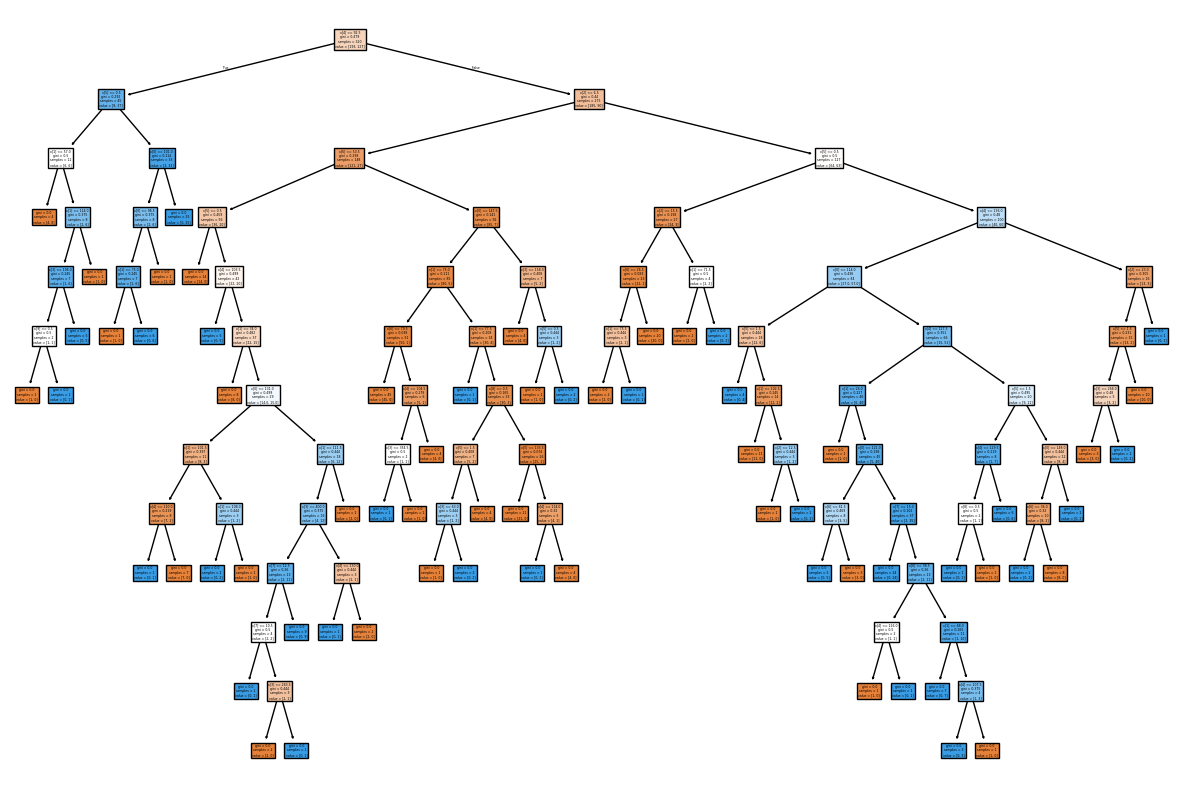

In [18]:
#Plot the tree
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(dtc,filled=True)
plt.show()

In [19]:
#What is the current depth of the tree
dtc.tree_.max_depth

12

In [20]:
#pruning the tree
dtc1 = DecisionTreeClassifier(max_depth=8,
                              min_samples_leaf=5,
                              min_samples_split=20
                            )
dtc1.fit(X_train,y_train)
##Predict values
y_pred = dtc1.predict(X_test)
#Calculate the accuracy of train and test
from sklearn.metrics import accuracy_score
print('Train Accuracy',accuracy_score(y_train,dtc1.predict(X_train)))
print('Test Accuracy',accuracy_score(y_test,y_pred))

Train Accuracy 0.853125
Test Accuracy 0.7375


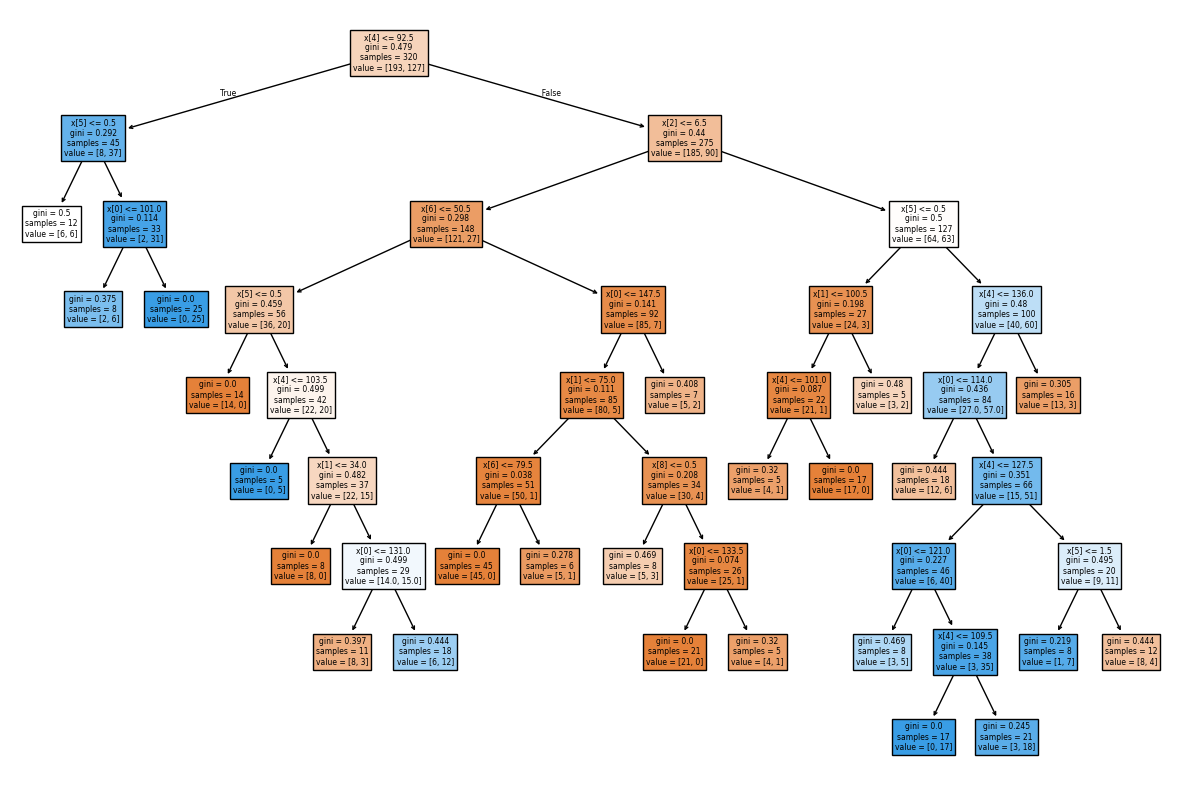

In [21]:
plt.figure(figsize=(15,10))
plot_tree(dtc1,filled=True)
plt.show()

In [22]:
#Use GridSearchCV to do Hyperpatrameter tuning
from sklearn.model_selection import GridSearchCV

In [23]:
param_grid = {
              'criterion':['gini','entropy'],
              'max_depth':[3,5,8],
              'min_samples_split':[5,10,15],
              'min_samples_leaf':[1,2,5]

}

In [24]:
grid_search = GridSearchCV(estimator=dtc,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 8], 'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [5, 10, 15]},
             scoring='accuracy')

In [25]:
#Which is the best combination of params
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 8,
 'min_samples_leaf': 5,
 'min_samples_split': 15}

In [26]:
#Which is the best model?
best_model = grid_search.best_estimator_

In [27]:
#Use your train test data split
#take the best model, with the best params and run the DTC again and see the best accuracy

best_model.fit(X_train,y_train)
#Predict values
y_pred = best_model.predict(X_test)
#Calculate the accuracy of train and test
from sklearn.metrics import accuracy_score
print('Train Accuracy',accuracy_score(y_train,best_model.predict(X_train)))
print('Test Accuracy',accuracy_score(y_test,y_pred))

Train Accuracy 0.871875
Test Accuracy 0.7875


In [28]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

In [29]:
rfc.fit(X_train,y_train)
y_pred=rfc.predict(X_test)

from sklearn.metrics import accuracy_score
print('Train Accuracy',accuracy_score(y_train,rfc.predict(X_train)))
print('Test Accuracy',accuracy_score(y_test,y_pred))

Train Accuracy 0.984375
Test Accuracy 0.8


In [30]:
n_estimators=[100,200,300]
param_grid={
    'n_estimators':[100,200,300],
    'criterion':['gini','entropy'],
    'max_depth':[5,10,15,20],
    'min_samples_split':[5,10,15,20],
    'min_samples_leaf':[1,2,5,10]

}

In [31]:
#grid_search=GridSearchCV(estimator=rfc,
                       param_grid=param_grid,
                       cv=5,
                       scoring='accuracy',
                       n_jobs=-1)
grid_search.fit(X_train,y_train)

IndentationError: unexpected indent (1119552914.py, line 2)

In [ ]:
grid_search.best_params_

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
#Use your train test data split
#take the best model, with the best params and run the DTC again and see the best accuracy

best_model.fit(X_train,y_train)
#Predict values
y_pred = best_model.predict(X_test)
#Calculate the accuracy of train and test
from sklearn.metrics import accuracy_score
print('Train Accuracy',accuracy_score(y_train,best_model.predict(X_train)))
print('Test Accuracy',accuracy_score(y_test,y_pred))

In [32]:
#AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
adb=AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.01,
    random_state=42
)
adb.fit(X_train,y_train)
y_pred=adb.predict(X_test)

from sklearn.metrics import accuracy_score
print("Train accuracy",accuracy_score(y_train,adb.predict(X_train)))
print("Test accuracy",accuracy_score(y_test,y_pred))


Train accuracy 0.7875
Test accuracy 0.7


In [33]:
y_pred


array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1])

In [34]:
param_grid={
    'n_estimators' : [100,200,200,400],
    'learning_rate' : [1,0.1,0.01,0.001]
}

In [35]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(
    estimator=adb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [36]:
grid_search.fit(X_train,y_train)
grid_search.best_params_

best_model=grid_search.best_params_


In [37]:
best_model

{'learning_rate': 1, 'n_estimators': 200}

In [38]:
grid_search.best_score_

np.float64(0.865625)

In [41]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.02,
    max_depth=3,
    random_state=42
)
gbc.fit(X_train,y_train)
y_pred-gbc.predict(X_test)

from sklearn.metrics import accuracy_score
print('Train accuracy score',accuracy_score(y_train,gbc.predict(X_train)))
print("Test accuracy score",accuracy_score(y_test,y_pred))

Train accuracy score 0.915625
Test accuracy score 0.7


In [47]:
param_grid = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.02],
    'max_depth':[3,4,5]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(
    estimator=gbc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)